In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import json
import statistics
import numpy as np


def std_bar(mean, std):
    tmp_mean = np.array(mean)
    tmp_std = np.array(std)
    
    return tmp_mean - tmp_std, tmp_mean + tmp_std


def plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach):


    d_names = {
        "rte":"RTE",
        "arc_challenge":"ARC Challenge",
        "openbookqa":"OpenBookQA",
        "boolq":"BoolQ",
        "arc_easy":"ARC Easy"
    }


    num = 16
        
    colors = {"s":"#fc5e03", "c":"#030ffc"}
    for dataset in datasets:
        
        if tmp_path_unpruned is not None:
            acc = 0
            s_unpruned = []
            c_unpruned = []
            
            for i in range(3):
                
                out_file = open(tmp_path_unpruned+model_name+"_"+fa_approach+"_res_3d_"+str(i)+".json", "r")
                out = json.load(out_file)
                out_file.close()
                
                s_unpruned.append(out[dataset]["suff"])
                c_unpruned.append(out[dataset]["comp"])
                
                out_file = open(tmp_path_unpruned+model_name+".json", "r")
                out = json.load(out_file)
                out_file.close()
                
                acc += out["results"][dataset]["acc,none"]
            
            acc/=3
           
            std_s_unpruned =  statistics.stdev(s_unpruned)
            s_unpruned= statistics.mean(s_unpruned)
            std_c_unpruned = statistics.stdev(c_unpruned)
            c_unpruned= statistics.mean(c_unpruned)
            

            
            
        suff = []
        comp = []
        
        std_suff = []
        std_comp = []
        
        accs = []

        for i in range(num):
            
            tmp_suff =[]
            tmp_comp = []
            tmp_accs = []
            
            
            for j in range(3):
                
                out_file = open(tmp_path+model_name+"_"+str(i)+"_"+fa_approach+"_res_3d_"+str(j)+".json", "r")
                out = json.load(out_file)
                out_file.close()
                
                tmp_suff.append(out[dataset]["suff"])
                tmp_comp.append(out[dataset]["comp"])
                
                
                
                out_file = open(tmp_path2+model_name+"_"+str(i)+".json", "r")
                out = json.load(out_file)
                out_file.close()
                
                tmp_accs.append(out["results"][dataset]["acc,none"])
        

            
            suff.append(statistics.mean(tmp_suff))
            comp.append(statistics.mean(tmp_comp))
            accs.append(statistics.mean(tmp_accs))
            
            std_suff.append(statistics.stdev(tmp_suff))
            std_comp.append(statistics.stdev(tmp_comp))
        
        # Comprehensiveness

        fig, ax1 = plt.subplots()
        ax2 = ax1.twinx()
        x_values = list(range(1, len(suff) + 1))
        l = len(x_values)
        
        if tmp_path_unpruned is not None:
            lns2 = ax1.plot(x_values, [c_unpruned]*l, label='comprehensiveness unpruned', color=colors["c"], linestyle='--')

        lns4 = ax1.plot(x_values, comp, label='comprehensiveness', color=colors["c"])

        y1, y2 = std_bar(comp, std_comp)
        ax1.fill_between(x_values, y1, y2, color=colors["c"], alpha=0.5)
        
        y1, y2 = std_bar([c_unpruned]*l, [std_c_unpruned]*l)
        ax1.fill_between(x_values, y1, y2, color=colors["c"], alpha=0.3)
        
        
        if tmp_path_unpruned is not None:
            lns5 = ax2.plot(x_values, [acc]*l, label='accuracy unpruned', color="black", linestyle='--')
        lns6 = ax2.plot(x_values, accs, label='accuracy', color="black")

        ax1.set_xlabel('# removed attention layers', fontsize=18)
        ax1.set_ylabel('Comprehensiveness', fontsize=18)
        ax2.set_ylabel('Accuracy', fontsize=18)

        plt.xticks(np.arange(2, 17, 2))
        ax1.tick_params(axis='both', which='major', labelsize=14)
        ax2.tick_params(axis='y', which='major', labelsize=14)
        plt.xlim(1,16)
    
        
        plt.title(d_names[dataset], fontsize=20)
        

        fig.tight_layout()
        plt.savefig("results/plots/comp/suff_comp_"+dataset+"_"+model_name+"_"+fa_approach+"_comprehensiveness.pdf", dpi=600)
        plt.show()
        
        # SUFFICIENCY
        
        fig, ax1 = plt.subplots()
        ax2 = ax1.twinx()
        x_values = list(range(1, len(suff) + 1))
        l = len(x_values)
        
        if tmp_path_unpruned is not None:
            lns1 = ax1.plot(x_values, [s_unpruned]*l, label='sufficiency unpruned', color=colors["s"], linestyle='--')

        lns3 = ax1.plot(x_values, suff, label='sufficiency', color=colors["s"])

        y1, y2 = std_bar(suff, std_suff)
        ax1.fill_between(x_values, y1, y2, color=colors["s"], alpha=0.5)
        
        
        y1, y2 = std_bar([s_unpruned]*l, [std_s_unpruned]*l)
        ax1.fill_between(x_values, y1, y2, color=colors["s"], alpha=0.3)

        
        if tmp_path_unpruned is not None:
            lns5 = ax2.plot(x_values, [acc]*l, label='accuracy unpruned', color="black", linestyle='--')
        lns6 = ax2.plot(x_values, accs, label='accuracy', color="black")

        ax1.set_xlabel('# removed attention layers', fontsize=18)
        ax1.set_ylabel('Sufficiency', fontsize=18)
        ax2.set_ylabel('Accuracy', fontsize=18)

        plt.xticks(np.arange(2, 17, 2))
        ax1.tick_params(axis='both', which='major', labelsize=14)
        ax2.tick_params(axis='y', which='major', labelsize=14)
        plt.xlim(1,16)
    
        
        plt.title(d_names[dataset], fontsize=20)

        fig.tight_layout()
        plt.savefig("results/plots/suff/suff_comp_"+dataset+"_"+model_name+"_"+fa_approach+"_sufficiency.pdf", dpi=600)
        plt.show()


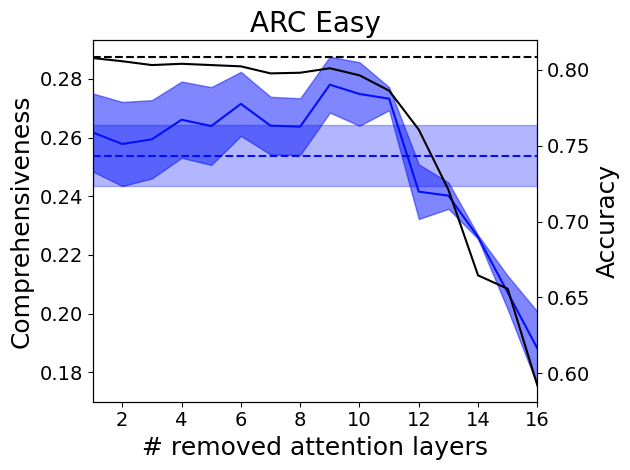

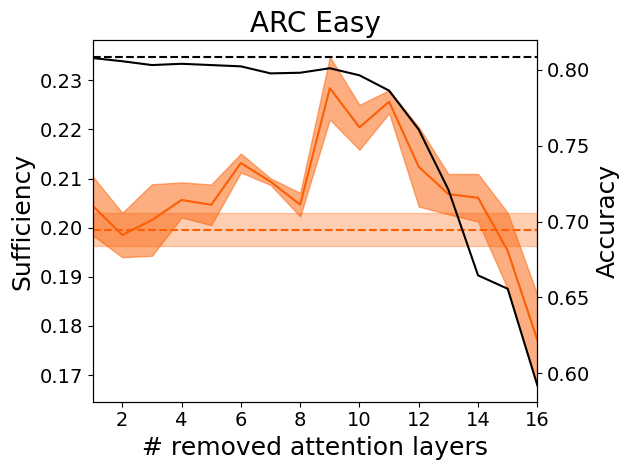

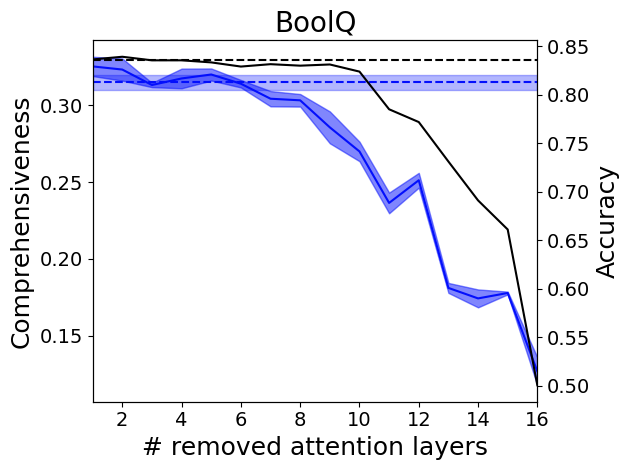

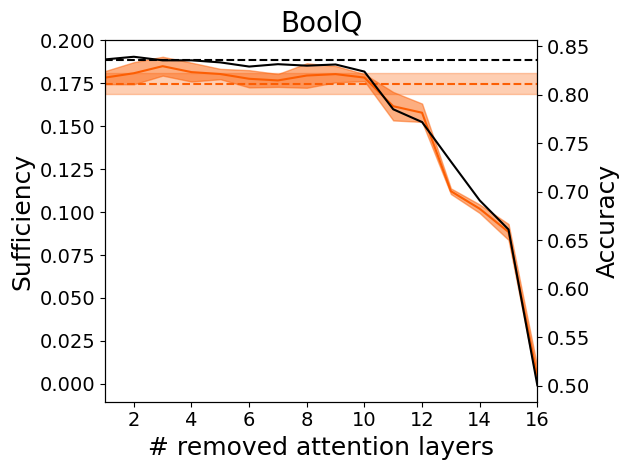

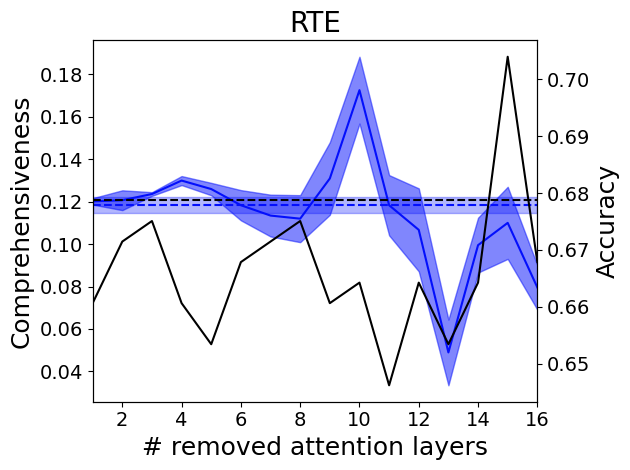

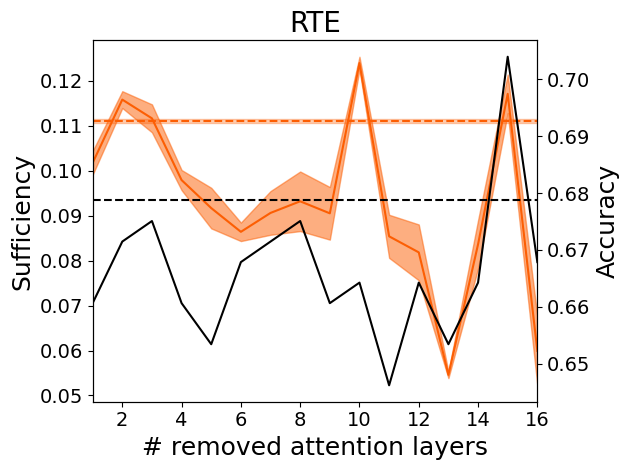

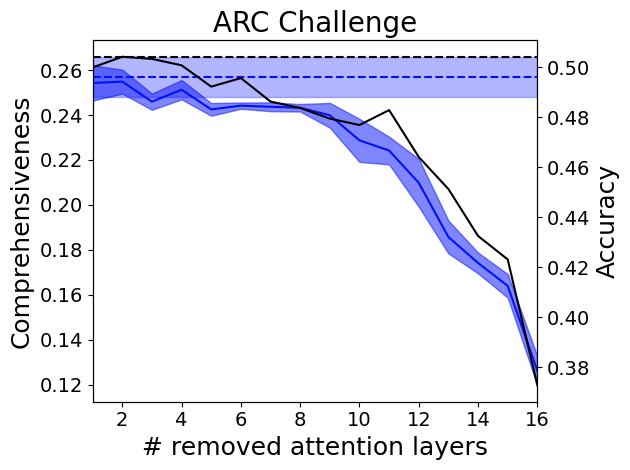

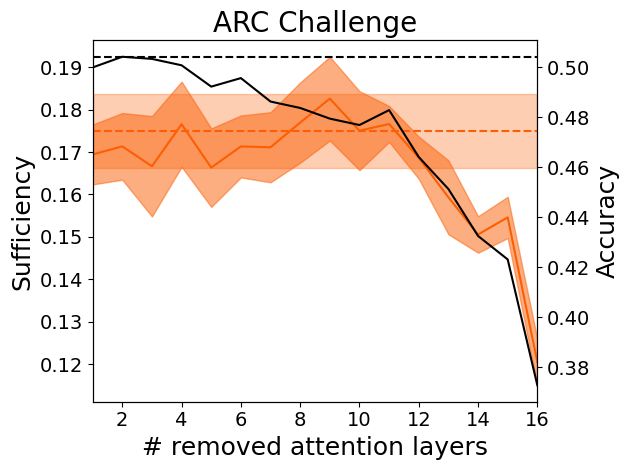

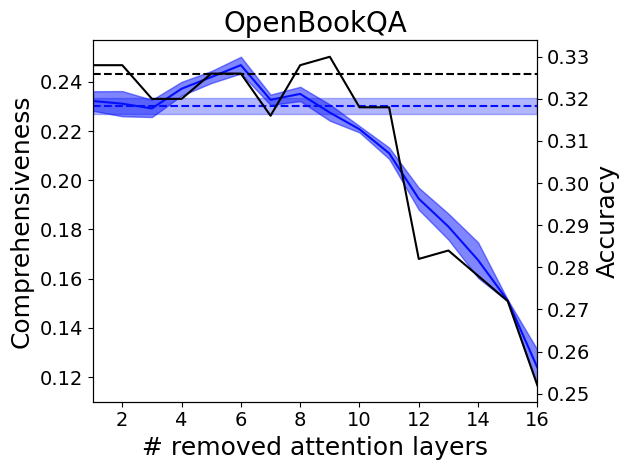

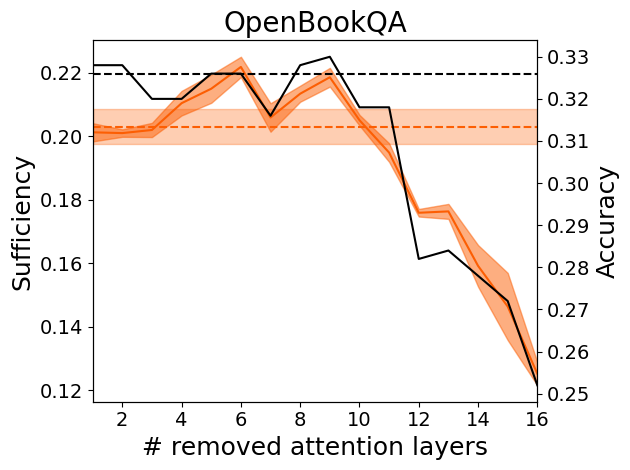

In [19]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Mistral-7B-v0.1"
tmp_path = "./results/pruned/seeds/mistralai/"
tmp_path2 = "./results/pruned/mistralai/"
tmp_path_unpruned = "./results/unpruned/seeds/mistralai/"
fa_approach = "ks"

plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach)

In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Mistral-7B-v0.1"
tmp_path = "./results/pruned/seeds/mistralai/"
tmp_path2 = "./results/pruned/mistralai/"
tmp_path_unpruned = "./results/unpruned/seeds/mistralai/"
fa_approach = "lime"

plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach)

In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Llama-2-7b-hf"
tmp_path = "./results/pruned/seeds/meta-llama/"
tmp_path2 = "./results/pruned/meta-llama/"
tmp_path_unpruned = "./results/unpruned/seeds/meta-llama/"
fa_approach = "lime"

plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach)

In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Llama-2-7b-hf"
tmp_path = "./results/pruned/seeds/meta-llama/"
tmp_path2 = "./results/pruned/meta-llama/"
tmp_path_unpruned = "./results/unpruned/seeds/meta-llama/"
fa_approach = "ks"

plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach)